# Customer Segmentation - Parte 1 (ML)

Notebook técnico do case: tratamento, clusterização e interpretação de segmentos.

## 1. Business Context

Objetivo: segmentar consumidores e gerar perfis de cluster interpretáveis para uso de negócio e futura camada de agentes.

## Ambiente e execução

Para garantir resolução correta de caminhos (`data/`, `ml-clustering/outputs/`), execute este notebook a partir da **raiz do repositório**.

Exemplo:

```bash
uv run jupyter notebook ml-clustering/notebooks/customer_segmentation_clustering.ipynb
```

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().resolve().parents[1]
SRC = ROOT / "ml-clustering" / "src"
if str(SRC) not in sys.path:
    sys.path.append(str(SRC))

from ml_clustering.data_loader import load_customer_data, validate_schema
from ml_clustering.preprocessing import prepare_features, build_preprocessing_pipeline
from ml_clustering.clustering import build_modeling_matrix, evaluate_kmeans_k_range, choose_k, fit_final_kmeans, project_pca_2d
from ml_clustering.profiling import build_cluster_summary, assign_segment_names
from ml_clustering.paths import DATA_PATH, OUTPUTS_DIR, FIGURES_DIR

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

## 2. Dataset Overview

In [2]:
df = load_customer_data(DATA_PATH)
df.shape

(3000, 11)

In [3]:
df.head()

,canal_preferido,categoria_favorita,regiao,marca_preferida,influenciador,frequencia_compra,pagamento,genero,ticket_medio,qtd_itens,data_nascimento
0,whatsapp,mercearia,nordeste,marca_52,influencer_062,quinzenal,credito,feminino,111.866313,3,12/09/1969
1,parceiros,limpeza,sudeste,marca_14,influencer_042,semanal,boleto,nao_informado,128.156105,6,13/01/1996
2,app,snacks,nordeste,marca_29,influencer_008,quinzenal,carteira_digital,outro,90.987727,6,22/08/1993
3,whatsapp,mercearia,sudeste,marca_01,influencer_118,bimestral,debito,outro,136.000269,3,22/06/1976
4,loja_fisica,bebidas,sudeste,marca_00,influencer_020,mensal,carteira_digital,nao_informado,144.617137,2,16/02/2007


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   canal_preferido     3000 non-null   str    
 1   categoria_favorita  3000 non-null   str    
 2   regiao              3000 non-null   str    
 3   marca_preferida     3000 non-null   str    
 4   influenciador       3000 non-null   str    
 5   frequencia_compra   3000 non-null   str    
 6   pagamento           3000 non-null   str    
 7   genero              3000 non-null   str    
 8   ticket_medio        3000 non-null   float64
 9   qtd_itens           3000 non-null   int64  
 10  data_nascimento     3000 non-null   str    
dtypes: float64(1), int64(1), str(9)
memory usage: 257.9 KB


## 3. Initial EDA

In [5]:
df.describe()

,ticket_medio,qtd_itens
count,3000.000000,3000.000000
mean,121.818805,4.028000
std,39.999201,1.988433
min,10.000000,0.000000
25%,94.951767,3.000000
50%,122.204219,4.000000
75%,147.962583,5.000000
max,253.098891,12.000000


In [6]:
df.describe(include="object")

/tmp/ipykernel_70306/702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,canal_preferido,categoria_favorita,regiao,marca_preferida,influenciador,frequencia_compra,pagamento,genero,data_nascimento
count,3000,3000,3000,3000,3000,3000,3000,3000,3000
unique,5,6,5,60,120,5,5,4,2766
top,loja_fisica,bebidas,sudeste,marca_29,influencer_078,semanal,credito,masculino,04/04/2003
freq,730,625,700,63,38,719,700,873,3


In [7]:
df.isna().sum()

canal_preferido       0
categoria_favorita    0
regiao                0
marca_preferida       0
influenciador         0
frequencia_compra     0
pagamento             0
genero                0
ticket_medio          0
qtd_itens             0
data_nascimento       0
dtype: int64

In [8]:
df.nunique().sort_values(ascending=False)

ticket_medio          2995
data_nascimento       2766
influenciador          120
marca_preferida         60
qtd_itens               13
categoria_favorita       6
canal_preferido          5
regiao                   5
frequencia_compra        5
pagamento                5
genero                   4
dtype: int64

## 3.1 EDA Visual Rápido

Visualizações simples para distribuição de variáveis numéricas e comportamento categórico.

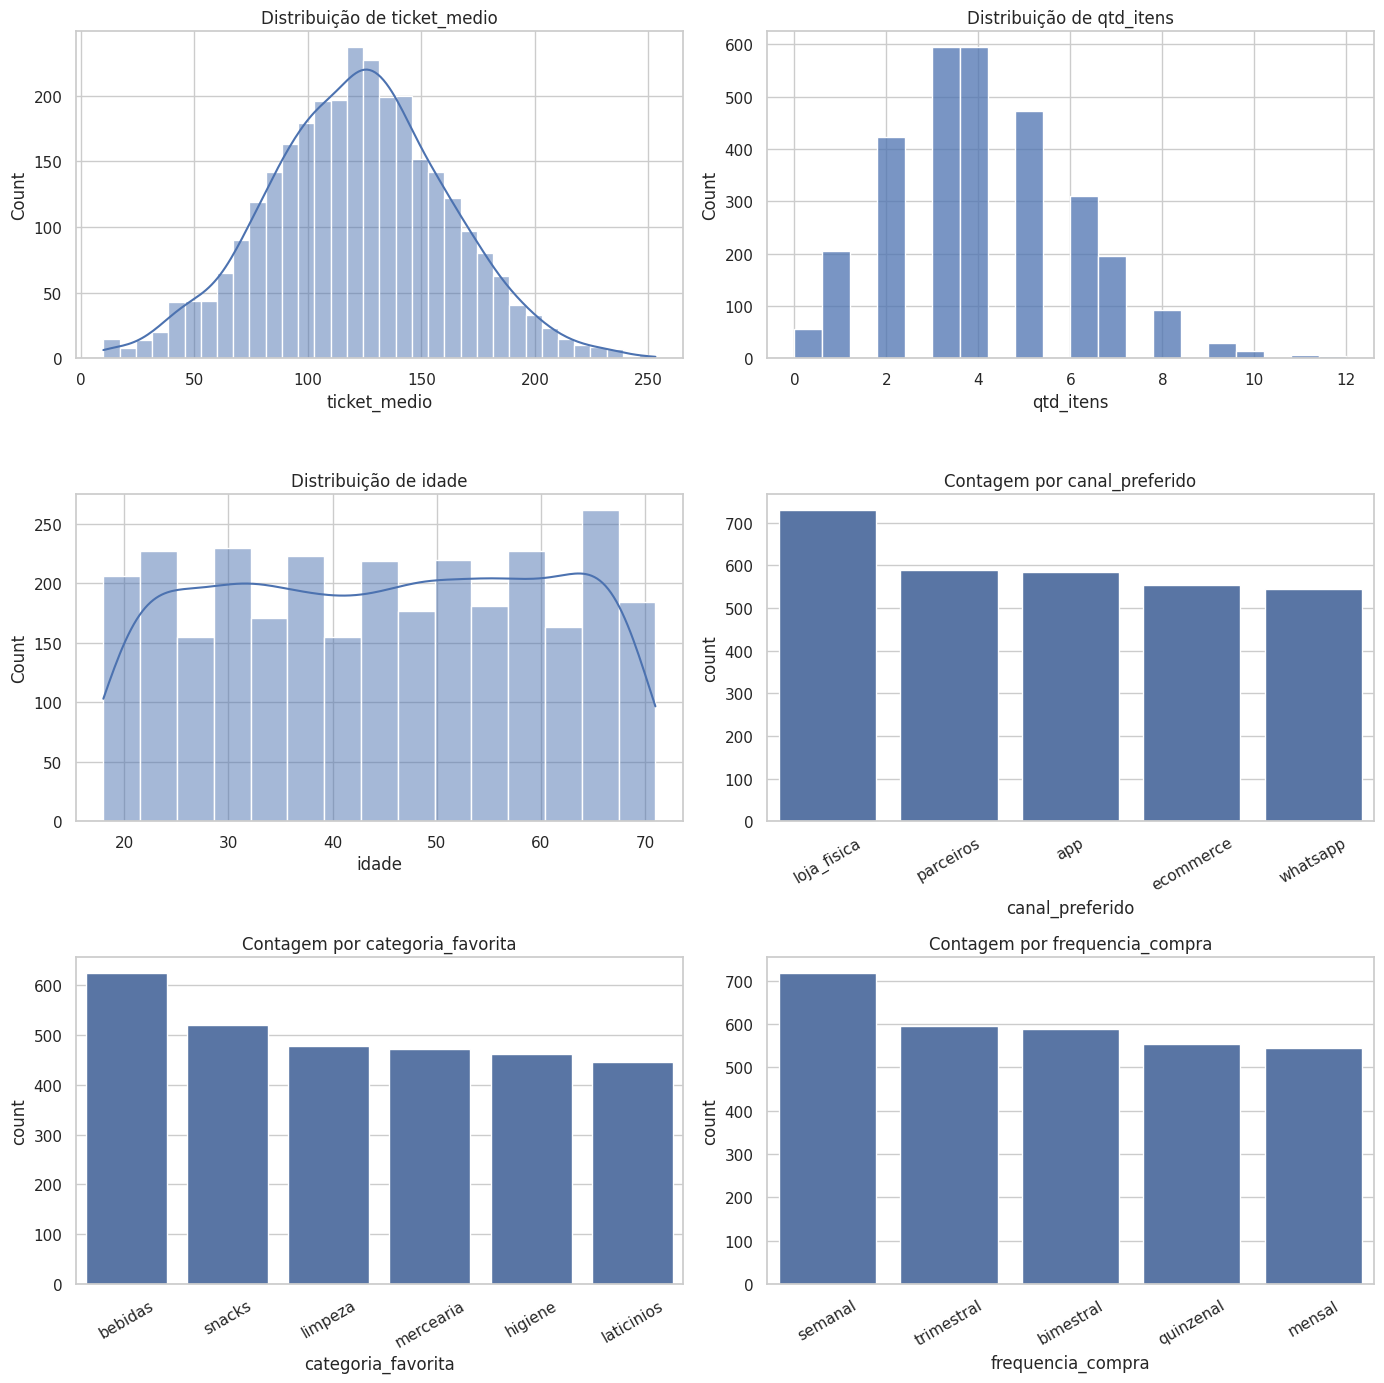

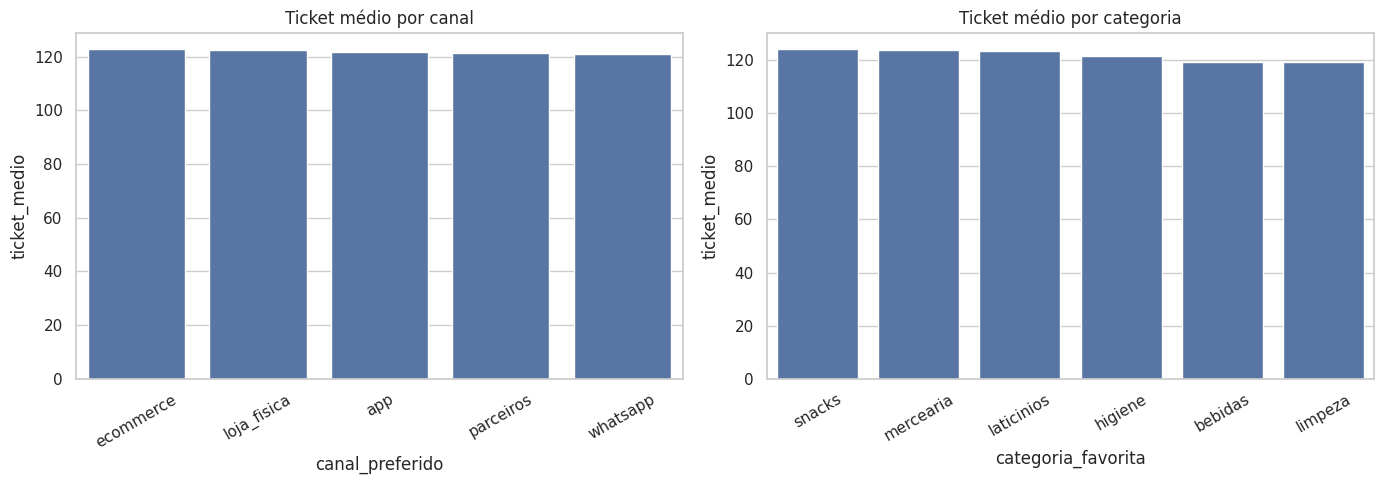

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
sns.histplot(df["ticket_medio"], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribuição de ticket_medio")

sns.histplot(df["qtd_itens"], kde=False, bins=20, ax=axes[0, 1])
axes[0, 1].set_title("Distribuição de qtd_itens")

df_tmp = df_reference if "df_reference" in globals() else prepare_features(df)[1]
sns.histplot(df_tmp["idade"].dropna(), kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Distribuição de idade")

sns.countplot(data=df, x="canal_preferido", order=df["canal_preferido"].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title("Contagem por canal_preferido")
axes[1, 1].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="categoria_favorita", order=df["categoria_favorita"].value_counts().index, ax=axes[2, 0])
axes[2, 0].set_title("Contagem por categoria_favorita")
axes[2, 0].tick_params(axis="x", rotation=30)

sns.countplot(data=df, x="frequencia_compra", order=df["frequencia_compra"].value_counts().index, ax=axes[2, 1])
axes[2, 1].set_title("Contagem por frequencia_compra")
axes[2, 1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ticket_by_channel = df.groupby("canal_preferido", as_index=False)["ticket_medio"].mean().sort_values("ticket_medio", ascending=False)
sns.barplot(data=ticket_by_channel, x="canal_preferido", y="ticket_medio", ax=axes[0])
axes[0].set_title("Ticket médio por canal")
axes[0].tick_params(axis="x", rotation=30)

ticket_by_category = df.groupby("categoria_favorita", as_index=False)["ticket_medio"].mean().sort_values("ticket_medio", ascending=False)
sns.barplot(data=ticket_by_category, x="categoria_favorita", y="ticket_medio", ax=axes[1])
axes[1].set_title("Ticket médio por categoria")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 4. Data Quality Checks

In [10]:
diagnostics = validate_schema(df)
diagnostics

{'row_count': 3000,
 'column_count': 11,
 'null_values': {'canal_preferido': 0,
  'categoria_favorita': 0,
  'regiao': 0,
  'marca_preferida': 0,
  'influenciador': 0,
  'frequencia_compra': 0,
  'pagamento': 0,
  'genero': 0,
  'ticket_medio': 0,
  'qtd_itens': 0,
  'data_nascimento': 0},
 'duplicated_rows': 0,
 'dtypes': {'canal_preferido': 'str',
  'categoria_favorita': 'str',
  'regiao': 'str',
  'marca_preferida': 'str',
  'influenciador': 'str',
  'frequencia_compra': 'str',
  'pagamento': 'str',
  'genero': 'str',
  'ticket_medio': 'float64',
  'qtd_itens': 'int64',
  'data_nascimento': 'str'}}

## 5. Feature Engineering

In [11]:
df_model, df_reference, numeric_features, categorical_features = prepare_features(df)

df_reference[["data_nascimento", "idade", "faixa_etaria", "marca_preferida_freq", "influenciador_freq"]].head()

,data_nascimento,idade,faixa_etaria,marca_preferida_freq,influenciador_freq
0,12/09/1969,56,55+,0.013000,0.008667
1,13/01/1996,30,25-34,0.020333,0.006667
2,22/08/1993,32,25-34,0.021000,0.005667
3,22/06/1976,49,45-54,0.017000,0.006333
4,16/02/2007,19,18-24,0.021000,0.009333


## 6. Categorical Encoding Strategy

- Alta cardinalidade (`marca_preferida`, `influenciador`): frequency encoding.
- Baixa cardinalidade: one-hot encoding.
- `frequencia_compra`: ordinal quando mapeável, senão one-hot.

In [12]:
numeric_features, categorical_features

(['idade',
  'ticket_medio',
  'qtd_itens',
  'marca_preferida_freq',
  'influenciador_freq'],
 ['canal_preferido',
  'categoria_favorita',
  'regiao',
  'pagamento',
  'genero',
  'frequencia_compra'])

## 7. Preprocessing Pipeline

In [13]:
preprocessor = build_preprocessing_pipeline(numeric_features, categorical_features)
X = preprocessor.fit_transform(df_model)
X_model, modeling_info = build_modeling_matrix(X, strategy="pca20")
modeling_info, X.shape, X_model.shape

({'modeling_strategy': 'pca_20',
  'modeling_components': 20,
  'explained_variance': 0.8468754688999306},
 (3000, 35),
 (3000, 20))

## 8. Dimensionality Reduction

In [14]:
pca_coords, explained = project_pca_2d(X_model)
explained

0.25069562099556686

## 9. Clustering Model Selection

In [15]:
metrics_df = evaluate_kmeans_k_range(X_model, k_min=2, k_max=8)
metrics_df

,k,inertia,silhouette_score,davies_bouldin_score,calinski_harabasz_score
0,2,22537.231283,0.089622,3.089959,304.133603
1,3,21112.345866,0.080472,2.757394,263.411703
2,4,20019.613475,0.078065,2.531126,239.640255
3,5,19135.888516,0.076101,2.374591,222.546084
4,6,18411.263655,0.076955,2.249985,208.549590
5,7,17881.797103,0.072766,2.358175,193.647469
6,8,17499.862578,0.070852,2.304088,178.878098


## 10. Internal Metrics

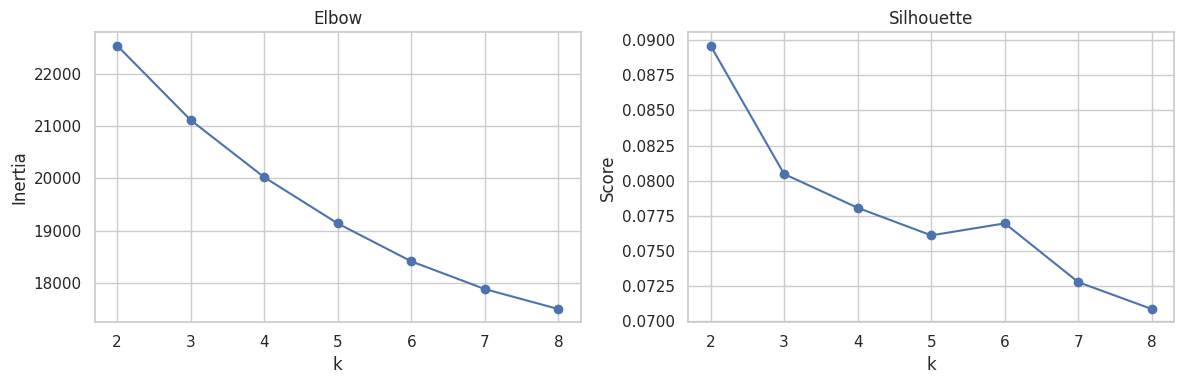

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(metrics_df["k"], metrics_df["inertia"], marker="o")
axes[0].set_title("Elbow")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(metrics_df["k"], metrics_df["silhouette_score"], marker="o")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

## 10.1 Critério de escolha de k (comparativo)

Comparação entre a regra orientada a negócio (faixa 3-5) e o melhor valor global por silhouette.

## Decisão de K (métrica vs negócio)

Embora `k=2` apresente o maior silhouette global, `k=3` foi escolhido por equilibrar:

- qualidade estatística ainda aceitável nas métricas internas;
- maior granularidade de segmentação para consumo de negócio;
- melhor aderência à camada agêntica (personas comparáveis na interface).

Em bases comportamentais com alta presença de variáveis categóricas, scores de silhouette mais baixos e sobreposição parcial entre grupos são esperados. Por isso, a seleção de `k` não foi feita apenas pelo melhor score numérico, mas pelo compromisso entre separação, interpretabilidade e acionabilidade.

In [17]:
best_global_silhouette_k = int(metrics_df.sort_values("silhouette_score", ascending=False).iloc[0]["k"])
pd.DataFrame([
    {
        "criterio": "Regra de negócio (3-5) + votação métricas",
        "k_escolhido": selected_k if 'selected_k' in globals() else choose_k(metrics_df, 3, 5),
    },
    {
        "criterio": "Melhor silhouette global",
        "k_escolhido": best_global_silhouette_k,
    },
])

,criterio,k_escolhido
0,Regra de negócio (3-5) + votação métricas,3
1,Melhor silhouette global,2


## 11. Final Clustering

In [18]:
selected_k = choose_k(metrics_df, preferred_min=3, preferred_max=5)
selected_k

3

In [19]:
model = fit_final_kmeans(X_model, n_clusters=selected_k)
labels = model.labels_

df_clusters = df_reference.copy()
df_clusters["cluster"] = labels
df_clusters.head()

,canal_preferido,categoria_favorita,regiao,marca_preferida,influenciador,frequencia_compra,pagamento,genero,ticket_medio,qtd_itens,data_nascimento,idade,faixa_etaria,marca_preferida_freq,influenciador_freq,cluster
0,whatsapp,mercearia,nordeste,marca_52,influencer_062,quinzenal,credito,feminino,111.866313,3,12/09/1969,56,55+,0.013000,0.008667,2
1,parceiros,limpeza,sudeste,marca_14,influencer_042,semanal,boleto,nao_informado,128.156105,6,13/01/1996,30,25-34,0.020333,0.006667,1
2,app,snacks,nordeste,marca_29,influencer_008,quinzenal,carteira_digital,outro,90.987727,6,22/08/1993,32,25-34,0.021000,0.005667,1
3,whatsapp,mercearia,sudeste,marca_01,influencer_118,bimestral,debito,outro,136.000269,3,22/06/1976,49,45-54,0.017000,0.006333,0
4,loja_fisica,bebidas,sudeste,marca_00,influencer_020,mensal,carteira_digital,nao_informado,144.617137,2,16/02/2007,19,18-24,0.021000,0.009333,1


## 12. Cluster Visualization

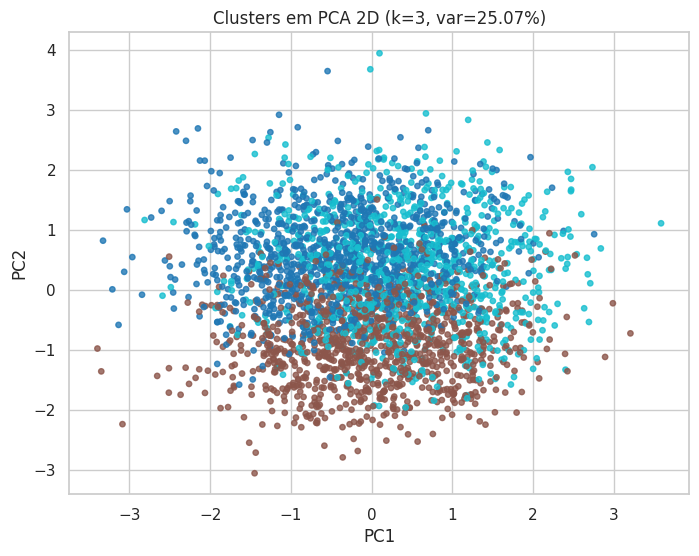

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(pca_coords[:, 0], pca_coords[:, 1], c=labels, s=15, cmap="tab10", alpha=0.8)
plt.title(f"Clusters em PCA 2D (k={selected_k}, var={explained:.2%})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## 13. Cluster Profiling

In [21]:
summary = build_cluster_summary(df_clusters)
summary = assign_segment_names(summary).sort_values("cluster").reset_index(drop=True)
summary

,cluster,cluster_size,idade_media,ticket_medio_medio,qtd_itens_medio,canal_preferido_modal,categoria_favorita_modal,regiao_modal,marca_preferida_modal,influenciador_modal,frequencia_compra_modal,pagamento_modal,genero_modal,faixa_etaria_modal,cluster_share,segment_name
0,0,1055,58.230332,120.452523,4.126066,loja_fisica,bebidas,norte,marca_00,influencer_011,semanal,carteira_digital,masculino,55+,0.351667,55+ - Ticket Médio - Loja Fisica - Semanal (No...
1,1,1027,29.997079,123.361748,3.794547,loja_fisica,bebidas,sudeste,marca_39,influencer_054,semanal,credito,masculino,25-34,0.342333,25-34 - Ticket Médio - Loja Fisica - Semanal (...
2,2,918,45.398693,121.662842,4.176471,loja_fisica,bebidas,sudeste,marca_22,influencer_046,semanal,credito,masculino,55+,0.306000,55+ - Ticket Médio - Loja Fisica - Semanal (Su...


## 14. Business Interpretation

In [22]:
summary[[
    "cluster",
    "segment_name",
    "cluster_share",
    "idade_media",
    "ticket_medio_medio",
    "canal_preferido_modal",
    "categoria_favorita_modal",
    "frequencia_compra_modal",
]].sort_values("cluster")

,cluster,segment_name,cluster_share,idade_media,ticket_medio_medio,canal_preferido_modal,categoria_favorita_modal,frequencia_compra_modal
0,0,55+ - Ticket Médio - Loja Fisica - Semanal (No...,0.351667,58.230332,120.452523,loja_fisica,bebidas,semanal
1,1,25-34 - Ticket Médio - Loja Fisica - Semanal (...,0.342333,29.997079,123.361748,loja_fisica,bebidas,semanal
2,2,55+ - Ticket Médio - Loja Fisica - Semanal (Su...,0.306000,45.398693,121.662842,loja_fisica,bebidas,semanal


## 15. Export for Agentic Layer

In [23]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

summary.to_csv(OUTPUTS_DIR / "cluster_summary.csv", index=False)
metrics_df.to_csv(OUTPUTS_DIR / "cluster_metrics.csv", index=False)
df_clusters.to_csv(OUTPUTS_DIR / "clustered_consumers.csv", index=False)

summary_path = OUTPUTS_DIR / "cluster_summary.csv"
metrics_path = OUTPUTS_DIR / "cluster_metrics.csv"
clusters_path = OUTPUTS_DIR / "clustered_consumers.csv"

summary_path, metrics_path, clusters_path

(PosixPath('/home/gcarvalho/Documentos/agentic-customer-intelligence/ml-clustering/outputs/cluster_summary.csv'),
 PosixPath('/home/gcarvalho/Documentos/agentic-customer-intelligence/ml-clustering/outputs/cluster_metrics.csv'),
 PosixPath('/home/gcarvalho/Documentos/agentic-customer-intelligence/ml-clustering/outputs/clustered_consumers.csv'))

## 16. Limitations and Next Steps

- Base sintética: resultados não devem ser tratados como verdade populacional.
- Clusterização não supervisionada depende fortemente de engenharia de atributos e encoding.
- Próximo passo de produção: validação com negócio, monitoramento e re-treinamento periódico.